# Probabilistic error cancellation (PEC) with Twirled Readout Error eXtinction (TREX)
In this guide we will show how to use PEC method to mitigate gates noise and how to combine it with TREX method to mitigate also measurement noise in estimating expectation values of observables.

[PEC](https://arxiv.org/pdf/1612.02058) returns an unbiased estimate of an expectation value of an observbale by executing an ensemble of noisy circuits, injected with the inverse of a learned noise model. The noise model is approximated to a Pauli channel by using Pauli twirling (also known as [randomized compiling](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.94.052325)). Such noise model can be learned efficiently and be mitigated using PEC (see [Probabilistic error cancellation with sparse Pauli-Lindblad models on noisy quantum
processors](https://arxiv.org/pdf/2201.09866) for more details).

In this guide we will show how to use PEC and TREX classes in ``qiskit-mitigation`` to mitigate gate and readout errors.
The guide uses a simulator, so no IBM Quantum® credentials are needed.

In this guide we will use these external package:
* `qiskit-noise-learning`
* `qiskitAer`

## Define a problem and prepare a circuit
In this guide we will prepare a mirror circuit of a Trotterized time evolution of a linear line transverse-field Ising model. By mirroring the circuit we cancel the circuit unitary to form an identity circuit. This allows us to easily compute the ideal expectation value of each observable. In addition, the mirroring doubles the depth of the circuit, which in turn doubles the effect of the noise. 

We will choose an angle of $\theta= \frac{\pi}{2}$ to keep all the gates in the circuit from the Clifford group, allowing faster simulation using `stabilizer` simultor.

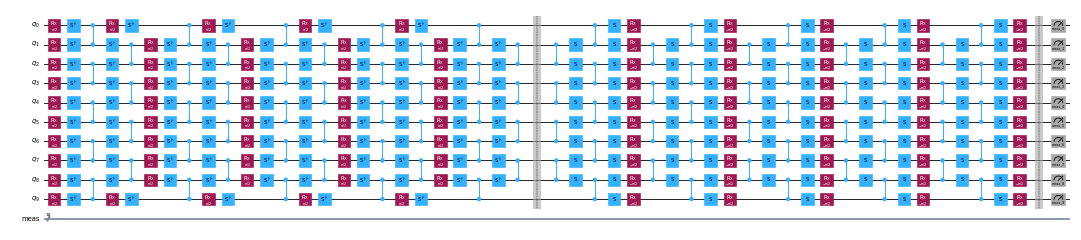

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit.circuit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp


def construct_ising_circuit(
    num_qubits: int, num_trotter_steps: int, rx_angle: float, barrier: bool = True
) -> QuantumCircuit:
    circuit = QuantumCircuit(num_qubits)

    for _step in range(num_trotter_steps):
        circuit.rx(rx_angle, range(num_qubits))
        if barrier:
            circuit.barrier()
        for first_qubit in (1, 2):
            for idx in range(first_qubit, num_qubits, 2):
                # equivalent to Rzz(-pi/2):
                circuit.sdg([idx - 1, idx])
                circuit.cz(idx - 1, idx)
        if barrier:
            circuit.barrier()

    return circuit


def mirror_circuit(circuit: QuantumCircuit) -> QuantumCircuit:
    mirror_circ = circuit.copy_empty_like()
    mirror_circ.compose(circuit, inplace=True)
    mirror_circ.barrier()
    mirror_circ.compose(circuit.inverse(), inplace=True)
    mirror_circ.measure_active()
    return mirror_circ


# define observables
num_qubits = 10
observables = [
    SparsePauliOp("I" * ((num_qubits - 1) - q) + "Z" + "I" * q) for q in range(num_qubits)
]

# Instantiate circuit
num_trotter_steps = 5
rx_angle = np.pi / 2

circuit = construct_ising_circuit(num_qubits, num_trotter_steps, rx_angle, barrier=False)
mirrored_circuit = mirror_circuit(circuit)
mirrored_circuit.draw("mpl", fold=-1, scale=0.3, idle_wires=False, measure_arrows=False)

## Twirl only execution
As a baseline for comparison, we will compute the results of gate twiling mitigation and also the noiseless results.
We will use Pauli twirling (also known as [randomized compiling](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.94.052325)), which has the effect of transforming any quantum channel into a Pauli channel. Pauli twirling can mitigate coherent noise because coherent noise tends to accumulate quadratically with the number of operations, whereas Pauli noise accumulates linearly.

First, we need to prepare a quantum program. Quantum program contains a quantum circuit and a samplex in a format suitable for the Executor primitive.
We can use the same quantum program to run all simulations. This is mainly important when executing on a real backend, to allow executing all the requested tasks in the same job.

We add "add_tags" to the boxing options, to allow the simulator map between the noise model and the boxes in the circuit to inject it to.

In [2]:
from qiskit_mitigation import MitigationTask

num_randomizations = 200
shots_per_randomization = 64
boxing_options = {
    "add_tags": "unique_box",
}

task_twirled = MitigationTask()
program = task_twirled.prepare(
    circuit=mirrored_circuit,
    observables=observables,
    parameters=None,
    num_randomizations=num_randomizations,
    shots_per_randomization=shots_per_randomization,
    custom_boxing_options=boxing_options,
)

## Create a noisy simulator
In this guide we will use a simulator that allows a `Samplex` as an input.
We will create a random noise model in the form of a `Pauli-Lindblad` channel for each uniqe layer of 2-qubit gates. This is an approximation of the twirled noise model. In addition, we will inject to each circuit readout noise in the form of random `X` gates before the measurements, to simulate incorrect readout.

In [3]:
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.quantum_info import PauliLindbladMap, pauli_basis
from qiskit.transpiler import PassManager
from qiskit_aer import AerSimulator
from qiskit_mitigation import find_combined_unique_layers
from qiskit_noise_learning.aer_executor import AerExecutor
from qiskit_noise_learning.aer_executor.insert_noise_pass import InsertNoisePass
from samplomatic import Tag
from samplomatic.utils import get_annotation


def generate_random_pauli_lindblad_noise(
    layers,
    num_qubits: int,
    noise_scale: float = 1e-3,
    readout_noise_scale: float = 3e-2,
    seed: int | None = None,
) -> tuple[dict[str, PauliLindbladMap], dict[str, PauliLindbladMap]]:
    """Generate random Pauli-Lindblad noise over the full Pauli basis."""
    gate_noise_dict = {}
    readout_noise_dict = {}
    for layer in layers:
        layer_instructions = layer.operation.params[0]
        contain_measurement = any(inst.name.startswith("measure") for inst in layer_instructions)
        layer_id = (
            get_annotation(layer.operation, Tag).ref
            if get_annotation(layer.operation, Tag)
            else None
        )
        if layer_id is None:
            continue
        if contain_measurement:
            rng = np.random.default_rng(seed=seed)
            rates = rng.random(num_qubits) * readout_noise_scale
            layer_noise = PauliLindbladMap.from_sparse_list(
                [("X", [q], rate) for q, rate in enumerate(rates)],
                num_qubits=num_qubits,
            )
            readout_noise_dict[layer_id] = layer_noise
        else:
            edges = [
                (inst.qubits[0]._index, inst.qubits[1]._index) for inst in layer_instructions
            ]  # extract the edges of the layer

            basis_paulis = [p for p in pauli_basis(2) if np.sum(p.x + p.z)]
            rng = np.random.default_rng(seed=seed)
            rates = rng.random(len(basis_paulis)) * noise_scale

            layer_noise = PauliLindbladMap.from_sparse_list(
                [
                    (pauli.to_label(), edge, rate)
                    for pauli, rate in zip(basis_paulis, rates, strict=True)
                    for edge in edges
                ],
                num_qubits=num_qubits,
            )
            gate_noise_dict[layer_id] = layer_noise
    return gate_noise_dict, readout_noise_dict


def add_readout_noise(program, readout_noise_map):
    readout_noise_model = next(iter(readout_noise_map))
    for item in program.items:
        readout_tag = item.circuit[-1].label[-4:]  # extract the readout layer tag from the circuit
        readout_noise_map[readout_tag] = readout_noise_model
        item.circuit = PassManager(
            [InsertNoisePass(noise_dict=readout_noise_map, noise_after=False)]
        ).run(item.circuit)


line_coupling = [(i, i + 1) for i in range(num_qubits - 1)]
backend = GenericBackendV2(
    num_qubits=num_qubits, basis_gates=["id", "rz", "sx", "x", "cz"], coupling_map=line_coupling
)

# find the unique layers to generate the layered noise for
box_layers = find_combined_unique_layers([mirrored_circuit], [task_twirled], boxing_options)

gate_noise_map, readout_noise_map = generate_random_pauli_lindblad_noise(
    box_layers, num_qubits, seed=42
)

# create a noisy simulator with the gates noise using the generated gate noise map
# The readout noise will be injected to each circuit directly
noisy_executor = AerExecutor(
    qasm_simulator=AerSimulator(method="stabilizer"), noise_dict=gate_noise_map
)

## PEC + TREX mitigation

### Noise learning
In order to use PEC, we must first learn the twirled noise model. We will find the unique circuit layers and learn the gate noise of each layer.

As opposed to the gate noise model, which is required for the program preperation in order to inject the anti-noise that corresponds to the learned noise model, the mitigation of the readout noise is done in post-processing.
Therefore, the readout noise can be either executed and learned along the learning of the gates noise, or along the execution of the mitigated program. Learning the readout noise alongside the gate noise is suggested in case a complex noise model which takes into account correlations between the gate and readout noise is learned. In case a simple noise model is learned, with gate and readout noise seperated, it is suggested to learn the readout noise along the execution of the mititgated program, to avoid as much as possible drifts in the noise between the learned time and the execution. In this guide we will learn the readout noise along the execution of the mitigated program.

In [4]:
import warnings

from qiskit_mitigation import PEC
from qiskit_noise_learning.noise_learner import LearningOptions, NoiseLearner
from samplomatic import InjectNoise

# We will ignore some warning regarding the absense of initialization error in the simulation
warnings.filterwarnings("ignore")

pec = PEC()
layers = pec.find_unique_layers(mirrored_circuit, boxing_options)

learning_options = LearningOptions(
    fragment_depths=[2, 4, 8, 16],
    num_randomizations=200,
    shots_per_randomizations=64,
)

learner = NoiseLearner(backend, options=learning_options, executor=noisy_executor)

noise_learn_job = learner.run(layers[:-1])  # do not learn the noise of the measurement layer
noise_learn_result = noise_learn_job.result()
learned_noise_res = noise_learn_result.to_dict()
learned_noise = {
    get_annotation(layer.operation, InjectNoise).ref: learned_noise_res[noise_key]
    for layer, noise_key in zip(layers[:-1], learned_noise_res.keys(), strict=True)
    if get_annotation(layer.operation, InjectNoise)
}

We create both a `TREX` and a `PEC` tasks, and add the trex task as a variable to the PEC task. This ensures that all the reiquired properties needed for TREX mitigation are added to the PEC mitigated item (like measurement twirling).

We add to the program also the TREX calibration circuit, in order to learn the readout noise along the execution of the program. The TREX calibration circuit is very shallow, making additinal randomizations for this item to be relatively cheap, allowing learning the readout noise more accuratly.

In [5]:
from qiskit_mitigation import TREX

trex = TREX()

program = pec.prepare(
    circuit=mirrored_circuit,
    observables=observables,
    parameters=None,
    num_randomizations=num_randomizations,
    shots_per_randomization=shots_per_randomization,
    custom_boxing_options=boxing_options,
    trex=trex,
    quantum_program=program,
    noise_maps=learned_noise,  # PEC option
    noise_gain=0,  # PEC option
    max_sampling_overhead=100,  # PEC option
)
program = trex.prepare(
    num_randomizations=300, quantum_program=program, custom_boxing_options=boxing_options
)

# For the simulation - we inject readout noise to the circuits of the program
add_readout_noise(program, readout_noise_map)

PEC returns an unbiased expectation value estimation, with a cost of large shot overhead. The required shot overhead can be approximated by calculating the circuit gamma factor, which reflects the effect of the learned noise model on the circuit. The number of randomization of the PEC task is scaled by default by the approximated amount of shots overheaed required to have an unbiased estimation (~$\gamma^2$). In order to avoid this automatic scale, one can set the parameter `scale_randomizations_by_gamma` to `False`. The shots overhead is capped by the `max_sampling_overhead` parameter.

It is advised to inspect the number of shots required by PEC to reach unbiased estimation before execution, to reason whether this amount is affordable, as this scale is exponential in the noise rates and depth of the circuit.

In [6]:
print(f"The circuit calculated gamma is: {pec.gamma}")
print(f"The circuit show overhead is ~{pec.gamma**2}")

The circuit calculated gamma is: 5.069517476097247
The circuit show overhead is ~25.700007440455405


In [7]:
job = noisy_executor.run(program)

results = job.result()

# post-processing
twirl_res = task_twirled.postprocess(results)
pec_res = pec.postprocess(results)
# In order to post process the results without TREX, we call `postprocess` again, but instead of the default options we
# pass only the PEC item result and the `measure_noise_data` as `None`
pec_without_trex_res = pec.postprocess(results[pec._program_item_index], measure_noise_data=None)

## Plotting the results
Readout error might have large effect on some observables in various cases, while mitigating it requires only small overhead of learning the readout noise.

We can see that by combining PEC and TREX mitigations, both gate and readout errors can be mitigated.

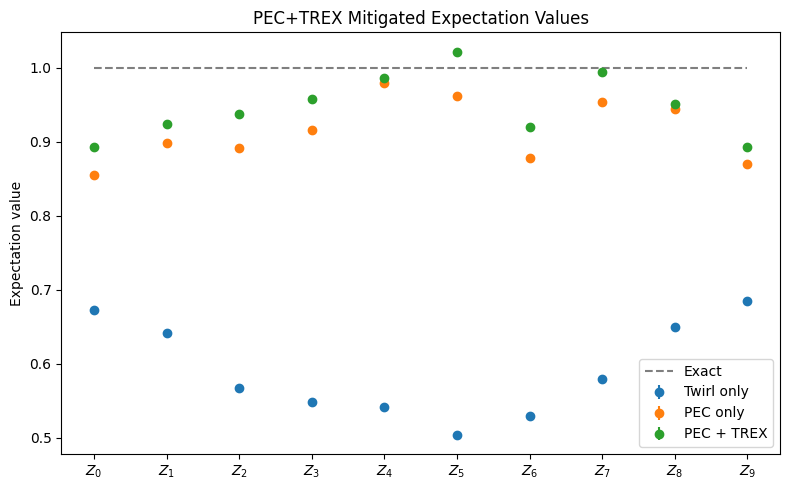

In [8]:
x = np.array(range(10))
x_tick_labels = [r"$Z_{ {i} }$" for i in range(10)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    x,
    twirl_res.data.evs,
    twirl_res.data.stds,
    fmt="o",
    label="Twirl only",
)
ax.errorbar(
    x,
    pec_without_trex_res.data.evs,
    pec_without_trex_res.data.stds,
    fmt="o",
    label="PEC only",
)
ax.errorbar(
    x,
    pec_res.data.evs,
    pec_res.data.stds,
    fmt="o",
    label="PEC + TREX",
)
ax.plot(x, [1] * len(x), "--", color="black", alpha=0.5, label="Exact")

tick_labels = [f"$Z_{ {i} }$" for i in range(10)]
ax.set_xticks(x, tick_labels)

ax.set_ylabel("Expectation value")
ax.legend()
ax.set_title("PEC+TREX Mitigated Expectation Values")
plt.tight_layout()
plt.show()